
Simulating single-cell RNA-seq-like data...

Dataset summary
Expression matrix shape: (1200, 2000)
Number of cells: 1200
Number of genes: 2000
Number of cell types: 4
Sparsity fraction: 0.7009

Representation: Raw genes
Number of features: 2000
Accuracy: 1.0000
Macro F1: 1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        75
           2       1.00      1.00      1.00        75
           3       1.00      1.00      1.00        75

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Representation: Highly variable genes
Number of features: 500
Accuracy: 1.0000
Macro F1: 1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.

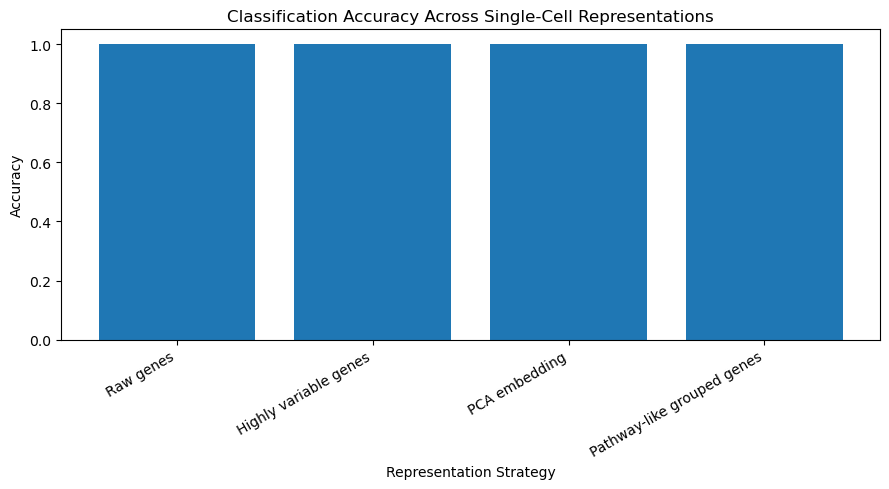

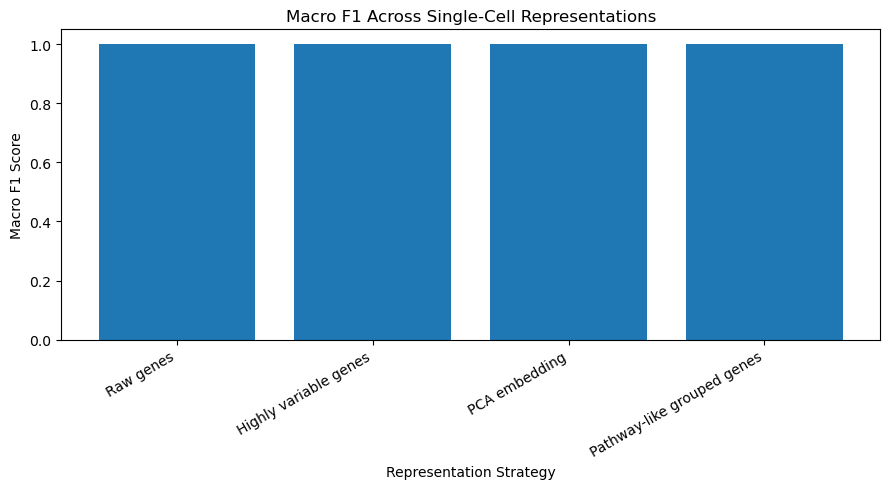


Saved figures to:
- accuracy_comparison.png
- macro_f1_comparison.png

Experiment complete.


In [7]:
"""
Single-Cell Tokenization / Representation Benchmark

Goal:
This script demonstrates how different representations of single-cell RNA-seq-like
data affect downstream machine learning performance.

Inspired by single-cell foundation model tokenization questions:
    How should a cell be represented before giving it to a model?

Representations compared:
1. Raw gene expression
2. Highly variable genes
3. PCA embedding
4. Pathway-like grouped genes

Author: Kazi Tanzina Begum
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report


# ============================================================
# 1. Simulate single-cell RNA-seq-like data
# ============================================================

def simulate_single_cell_data(
    n_cells=1200,
    n_genes=2000,
    n_cell_types=4,
    marker_genes_per_type=100,
    dropout_rate=0.55,
    random_state=42
):
    """
    Simulate a simple single-cell RNA-seq-like dataset.

    Each cell type has a group of marker genes with higher expression.
    Dropout is added to mimic sparsity in real single-cell data.
    """

    np.random.seed(random_state)

    cells_per_type = n_cells // n_cell_types

    X_list = []
    y_list = []

    for cell_type in range(n_cell_types):
        # Baseline expression for all genes
        base_expression = np.random.gamma(
            shape=1.5,
            scale=1.0,
            size=n_genes
        )

        # Add marker gene signal for each cell type
        marker_start = cell_type * marker_genes_per_type
        marker_end = marker_start + marker_genes_per_type
        base_expression[marker_start:marker_end] += 4.0

        # Generate count-like expression values
        X_type = np.random.poisson(
            lam=base_expression,
            size=(cells_per_type, n_genes)
        )

        # Add dropout / sparsity
        dropout_mask = np.random.rand(*X_type.shape) < dropout_rate
        X_type[dropout_mask] = 0

        X_list.append(X_type)
        y_list.extend([cell_type] * cells_per_type)

    X = np.vstack(X_list)
    y = np.array(y_list)

    return X, y


# ============================================================
# 2. Representation / tokenization strategies
# ============================================================

def raw_gene_representation(X):
    """
    Representation 1:
    Use all genes directly as model input.
    """
    return X


def highly_variable_gene_representation(X, top_k=500):
    """
    Representation 2:
    Select the most variable genes.

    This mimics highly variable gene selection, a common preprocessing step
    in single-cell analysis.
    """
    gene_variances = np.var(X, axis=0)
    top_gene_indices = np.argsort(gene_variances)[-top_k:]

    return X[:, top_gene_indices]


def pca_representation(X, n_components=50):
    """
    Representation 3:
    Compress the expression matrix into a lower-dimensional PCA embedding.
    """

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    explained_variance = pca.explained_variance_ratio_.sum()

    return X_pca, explained_variance


def pathway_like_representation(X, genes_per_pathway=50):
    """
    Representation 4:
    Group genes into pathway-like modules.

    This is a toy version of biologically informed tokenization.
    Instead of each gene being a separate feature, groups of genes are averaged.
    """

    n_cells, n_genes = X.shape
    n_pathways = n_genes // genes_per_pathway

    X_trimmed = X[:, :n_pathways * genes_per_pathway]

    X_pathway = X_trimmed.reshape(
        n_cells,
        n_pathways,
        genes_per_pathway
    ).mean(axis=2)

    return X_pathway


# ============================================================
# 3. Model training and evaluation
# ============================================================

def evaluate_representation(X_rep, y, representation_name):
    """
    Train a logistic regression classifier and evaluate performance.
    """

    X_train, X_test, y_train, y_test = train_test_split(
        X_rep,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    model = LogisticRegression(
        max_iter=3000,
        solver="lbfgs"
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    print("\n" + "=" * 70)
    print(f"Representation: {representation_name}")
    print("=" * 70)
    print(f"Number of features: {X_rep.shape[1]}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    return {
        "Representation": representation_name,
        "Number of Features": X_rep.shape[1],
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    }


# ============================================================
# 4. Plot results
# ============================================================

def plot_results(results_df):
    """
    Create bar plots for accuracy and macro F1.
    """

    plt.figure(figsize=(9, 5))
    plt.bar(results_df["Representation"], results_df["Accuracy"])
    plt.ylabel("Accuracy")
    plt.xlabel("Representation Strategy")
    plt.title("Classification Accuracy Across Single-Cell Representations")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("accuracy_comparison.png", dpi=300)
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.bar(results_df["Representation"], results_df["Macro F1"])
    plt.ylabel("Macro F1 Score")
    plt.xlabel("Representation Strategy")
    plt.title("Macro F1 Across Single-Cell Representations")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("macro_f1_comparison.png", dpi=300)
    plt.show()


# ============================================================
# 5. Main experiment
# ============================================================

def main():

    print("\nSimulating single-cell RNA-seq-like data...\n")

    X, y = simulate_single_cell_data()

    print("Dataset summary")
    print("=" * 70)
    print(f"Expression matrix shape: {X.shape}")
    print(f"Number of cells: {X.shape[0]}")
    print(f"Number of genes: {X.shape[1]}")
    print(f"Number of cell types: {len(np.unique(y))}")
    print(f"Sparsity fraction: {np.mean(X == 0):.4f}")

    results = []

    # Representation 1: raw genes
    X_raw = raw_gene_representation(X)
    results.append(
        evaluate_representation(
            X_raw,
            y,
            "Raw genes"
        )
    )

    # Representation 2: highly variable genes
    X_hvg = highly_variable_gene_representation(X, top_k=500)
    results.append(
        evaluate_representation(
            X_hvg,
            y,
            "Highly variable genes"
        )
    )

    # Representation 3: PCA
    X_pca, explained_variance = pca_representation(X, n_components=50)
    print(f"\nPCA explained variance using 50 components: {explained_variance:.4f}")

    results.append(
        evaluate_representation(
            X_pca,
            y,
            "PCA embedding"
        )
    )

    # Representation 4: pathway-like grouped genes
    X_pathway = pathway_like_representation(X, genes_per_pathway=50)
    results.append(
        evaluate_representation(
            X_pathway,
            y,
            "Pathway-like grouped genes"
        )
    )

    # Save summary results
    results_df = pd.DataFrame(results)

    print("\n\nFinal Summary Table")
    print("=" * 70)
    print(results_df)

    results_df.to_csv(
        "tokenization_comparison_results.csv",
        index=False
    )

    print("\nSaved results to:")
    print("- tokenization_comparison_results.csv")

    plot_results(results_df)

    print("\nSaved figures to:")
    print("- accuracy_comparison.png")
    print("- macro_f1_comparison.png")

    print("\nExperiment complete.")


if __name__ == "__main__":
    main()